# 在你的数据集上训练 Action-Chunking-Transformer (ACT)
在你的自定义数据集上训练 ACT 模型。本示例中 chunk_size 设为 10。


## ACT 算法背景与上下文（给初学者）

ACT（Action Chunking Transformer）是一个从视觉+状态直接预测一段动作序列的模仿学习策略。

这个 notebook 的核心目标：
1. 从数据集读取观测（图像、状态）与动作标签。
2. 训练 ACTPolicy 学会在每个时刻预测 `chunk_size` 长度的动作片段。
3. 在推理时滚动执行预测动作，并与真实动作对比误差。

为什么要 Action Chunking：
- 单步动作回归容易抖动且短视。
- 一次预测多步动作可以提升时间一致性与执行稳定性。
- 在固定采样频率（例如 20Hz）下，多步预测更接近短期规划。

你当前任务中的数据模态：
- 输入：`observation.image`（相机图像）+ `observation.state`（状态）。
- 输出：`action`（7 维，6 关节 + 1 夹爪）。


In [1]:
import torch

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.common.datasets.utils import dataset_to_policy_features
from lerobot.common.policies.act.configuration_act import ACTConfig
from lerobot.common.policies.act.modeling_act import ACTPolicy
from lerobot.configs.types import FeatureType
from lerobot.common.datasets.factory import resolve_delta_timestamps
import torchvision
import env_config
import os
os.environ["HF_DATASETS_CACHE"] = "./.hf_cache_py310"

[Env Info] 运行环境已就绪，当前工作目录: C:\Users\kewei\lerobot-mujoco-tutorial


In [2]:
device = torch.device("cuda")

# Number of offline training steps (we'll only do offline training for this example.)
# Adjust as you prefer. 5000 steps are needed to get something worth evaluating.
training_steps = 5000
log_freq = 100

## 策略配置与初始化

chunk_size = 10


In [3]:
# When starting from scratch (i.e. not from a pretrained policy), we need to specify 2 things before
# creating the policy:
#   - input/output shapes: to properly size the policy
#   - dataset stats: for normalization and denormalization of input/outputs
dataset_metadata = LeRobotDatasetMetadata("datawhale_eai_pnp", root='./demo_data')
features = dataset_to_policy_features(dataset_metadata.features)
output_features = {key: ft for key, ft in features.items() if ft.type is FeatureType.ACTION}
input_features = {key: ft for key, ft in features.items() if key not in output_features}
input_features.pop("observation.wrist_image")
# Policies are initialized with a configuration class, in this case `DiffusionConfig`. For this example,
# we'll just use the defaults and so no arguments other than input/output features need to be passed.
cfg = ACTConfig(input_features=input_features, output_features=output_features, chunk_size= 10, n_action_steps=10)
# This allows us to construct the data with action chunking
delta_timestamps = resolve_delta_timestamps(cfg, dataset_metadata)
# We can now instantiate our policy with this config and the dataset stats.
policy = ACTPolicy(cfg, dataset_stats=dataset_metadata.stats)
policy.train()
policy.to(device)

ACTPolicy(
  (normalize_inputs): Normalize(
    (buffer_observation_image): ParameterDict(
        (mean): Parameter containing: [torch.cuda.FloatTensor of size 3x1x1 (cuda:0)]
        (std): Parameter containing: [torch.cuda.FloatTensor of size 3x1x1 (cuda:0)]
    )
    (buffer_observation_state): ParameterDict(
        (mean): Parameter containing: [torch.cuda.FloatTensor of size 6 (cuda:0)]
        (std): Parameter containing: [torch.cuda.FloatTensor of size 6 (cuda:0)]
    )
  )
  (normalize_targets): Normalize(
    (buffer_action): ParameterDict(
        (mean): Parameter containing: [torch.cuda.FloatTensor of size 7 (cuda:0)]
        (std): Parameter containing: [torch.cuda.FloatTensor of size 7 (cuda:0)]
    )
  )
  (unnormalize_outputs): Unnormalize(
    (buffer_action): ParameterDict(
        (mean): Parameter containing: [torch.cuda.FloatTensor of size 7 (cuda:0)]
        (std): Parameter containing: [torch.cuda.FloatTensor of size 7 (cuda:0)]
    )
  )
  (model): ACT(
    (v

## ACT 模型结构导图（Mermaid）

```mermaid
flowchart TD
    A["Batch 输入\nobservation.image: (B, C, H, W)\nobservation.state: (B, S)\naction 标签: (B, T, A)"] --> B1["Normalize Inputs\nimage/state 按统计量归一化"]
    B1 --> C1["视觉 Backbone (ResNet)\n提取图像特征"]
    B1 --> C2["状态投影\nLinear(S->D)"]
    C1 --> D1["Transformer Encoder\n融合视觉 token + 状态 token + 潜变量 token"]
    C2 --> D1
    D1 --> E1["Transformer Decoder\n按 chunk_size 生成动作序列"]
    E1 --> F1["Action Head\nLinear(D->A)"]
    F1 --> G1["Predicted Actions\n(B, T, A)"]
    G1 --> H1["Unnormalize Outputs\n恢复动作物理尺度"]
    H1 --> I1["损失计算（训练）\n与 GT action 对齐"]
```

符号说明：
- `B`: batch size
- `T`: chunk_size（一次预测的动作步数）
- `A`: action 维度（本项目是 7）
- `D`: hidden dim（你的模型里是 512）


## 加载数据集


In [4]:
from torchvision import transforms

class AddGaussianNoise(object):
    """
    Adds Gaussian noise to a tensor.
    """
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Adds noise: tensor remains a tensor.
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

# Create a transformation pipeline that converts a PIL image to a tensor, then adds noise.
class Clamp01(object):
    def __call__(self, tensor):
        return tensor.clamp(0, 1)


transform = transforms.Compose([
    AddGaussianNoise(mean=0., std=0.02),
    Clamp01(),
])



In [5]:
# Remove-Item -Recurse -Force "$env:USERPROFILE\.cache\huggingface\datasets\parquet"

In [6]:
# Patch lerobot image transform for parquet rows that decode images as dict{'bytes','path'}
import io
import torch
import torchvision.transforms as T
from PIL import Image

import lerobot.common.datasets.utils as ds_utils
import lerobot.common.datasets.lerobot_dataset as ds_mod

def hf_transform_to_torch_patched(items_dict):
    to_tensor = T.ToTensor()
    for key in items_dict:
        first_item = items_dict[key][0]

        # Case 1: normal PIL images
        if isinstance(first_item, Image.Image):
            items_dict[key] = [to_tensor(img) for img in items_dict[key]]

        # Case 2: dict image payload from parquet: {'bytes': ..., 'path': ...}
        elif isinstance(first_item, dict) and ("bytes" in first_item or "path" in first_item):
            out = []
            for x in items_dict[key]:
                if isinstance(x, dict) and x.get("bytes") is not None:
                    img = Image.open(io.BytesIO(x["bytes"])).convert("RGB")
                    out.append(to_tensor(img))
                else:
                    # fallback: keep as is
                    out.append(x)
            items_dict[key] = out

        elif first_item is None:
            pass
        else:
            items_dict[key] = [x if isinstance(x, str) else torch.tensor(x) for x in items_dict[key]]
    return items_dict

# patch both references used by lerobot
ds_utils.hf_transform_to_torch = hf_transform_to_torch_patched
ds_mod.hf_transform_to_torch = hf_transform_to_torch_patched

print("patched hf_transform_to_torch")


patched hf_transform_to_torch


In [7]:
# We can then instantiate the dataset with these delta_timestamps configuration.
dataset = LeRobotDataset("datawhale_eai_pnp", delta_timestamps=delta_timestamps, root='./demo_data', image_transforms=transform)

# Then we create our optimizer and dataloader for offline training.
import os
num_workers = 0 if os.name == "nt" else 4
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-4)
dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=num_workers,
    batch_size=64,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)



## 输入输出与 Shape 说明

从你打印的 `ACTPolicy` 结构可见：
- `normalize_inputs`：对图像与状态做标准化。
- `normalize_targets`：训练时对动作标签标准化。
- `unnormalize_outputs`：推理时把预测动作还原到原尺度。
- `model.backbone`：图像编码（ResNet）。
- `model.encoder / model.decoder`：Transformer 主干。
- `model.action_head`：输出动作维度。

本 notebook 里每个 batch 的主要键：
- `observation.image`
- `observation.state`
- `action`

下面两个代码单元会：
1. 打印一个 batch 的每个字段 shape。
2. 对关键模块挂 forward hook，打印中间张量 shape。

这样你能清楚看到每个 batch 如何流经模型并产生 loss。


In [7]:
# from pathlib import Path
# import pyarrow.parquet as pq

# root = Path("./demo_data/data")
# files = sorted(root.rglob("*.parquet"))
# print("parquet files:", len(files))

# for f in files:
#     table = pq.read_table(f)
#     md = dict(table.schema.metadata or {})
#     if b"huggingface" in md:
#         del md[b"huggingface"]
#         table = table.replace_schema_metadata(md if md else None)
#         pq.write_table(table, f)
#         print("patched:", f)

# print("done")
# 上面主要是将py311保存的数据改为py310版本

parquet files: 1
patched: demo_data\data\chunk-000\episode_000000.parquet
done


In [8]:
# ===== Shape 1=====
print('===== Dataset / Policy Feature Summary =====')
print('Input features:')
for k, ft in input_features.items():
    print(f'  - {k}: type={ft.type}, shape={ft.shape}')

print('Output features:')
for k, ft in output_features.items():
    print(f'  - {k}: type={ft.type}, shape={ft.shape}')

sample_batch = next(iter(dataloader))
print('===== One Batch Tensor Shapes =====')
for k, v in sample_batch.items():
    if isinstance(v, torch.Tensor):
        print(f'{k:30s} shape={tuple(v.shape)} dtype={v.dtype}')
    else:
        print(f'{k:30s} type={type(v)}, len={len(k)}')


===== Dataset / Policy Feature Summary =====
Input features:
  - observation.image: type=VISUAL, shape=(3, 256, 256)
  - observation.state: type=STATE, shape=(6,)
Output features:
  - action: type=ACTION, shape=(7,)
===== One Batch Tensor Shapes =====
observation.image              shape=(64, 3, 256, 256) dtype=torch.float32
observation.wrist_image        shape=(64, 3, 256, 256) dtype=torch.float32
observation.state              shape=(64, 6) dtype=torch.float32
action                         shape=(64, 10, 7) dtype=torch.float32
obj_init                       shape=(64, 6) dtype=torch.float32
timestamp                      shape=(64,) dtype=torch.float32
frame_index                    shape=(64,) dtype=torch.int64
episode_index                  shape=(64,) dtype=torch.int64
index                          shape=(64,) dtype=torch.int64
task_index                     shape=(64,) dtype=torch.int64
action_is_pad                  shape=(64, 10) dtype=torch.bool
task                         

In [9]:
# ===== Shape 2 forward shape =====
from collections import OrderedDict


def shape_repr(x):
    if isinstance(x, torch.Tensor):
        return tuple(x.shape)
    if isinstance(x, dict):
        return {k: shape_repr(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [shape_repr(v) for v in x]
    return type(x).__name__


hook_records = OrderedDict()


def make_hook(name):
    def _hook(module, inputs, outputs):
        hook_records[name] = {
            'in': shape_repr(inputs),
            'out': shape_repr(outputs),
        }
    return _hook



named_modules = OrderedDict([
    ('normalize_inputs', policy.normalize_inputs),
    ('backbone', policy.model.backbone),
    ('encoder', policy.model.encoder),
    ('decoder', policy.model.decoder),
    ('action_head', policy.model.action_head),
])

handles = [m.register_forward_hook(make_hook(n)) for n, m in named_modules.items()]

inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in sample_batch.items()}
with torch.no_grad():
    loss, out_dict = policy.forward(inp_batch)

for h in handles:
    h.remove()

print('===== Forward Hook Shape Trace =====')
for name, rec in hook_records.items():
    print(f'[{name}]')
    print('  in :', rec['in'])
    print('  out:', rec['out'])

print('loss =', float(loss.item()))
print('out_dict keys =', list(out_dict.keys()) if isinstance(out_dict, dict) else type(out_dict))


===== Forward Hook Shape Trace =====
[normalize_inputs]
  in : [{'observation.image': (64, 3, 256, 256), 'observation.wrist_image': (64, 3, 256, 256), 'observation.state': (64, 6), 'action': (64, 10, 7), 'obj_init': (64, 6), 'timestamp': (64,), 'frame_index': (64,), 'episode_index': (64,), 'index': (64,), 'task_index': (64,), 'action_is_pad': (64, 10), 'task': ['str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str', 'str']}]
  out: {'observation.image': (64, 3, 256, 256), 'observation.wrist_image': (64, 3, 256, 256), 'observation.state': (64, 6), 'action': (64, 10, 7), 'obj_init': (64, 6), 'timestamp': (64,)

## 每个 Batch 是如何迭代并更新参数的

训练循环逻辑可概括为：
1. 从 `dataloader` 取出一个 batch。
2. 搬到 GPU：`inp_batch = {k: v.to(device) ...}`。
3. `loss, _ = policy.forward(inp_batch)`。
4. `loss.backward()` 反向传播。
5. `optimizer.step()` 更新参数。
6. `optimizer.zero_grad()` 清梯度。

可以理解为：
- 数据流：`batch -> model -> loss`
- 梯度流：`loss -> model parameters`

建议同时观察：
- loss 曲线
- 学习率
- 梯度范数
- 推理误差（mean action error）


## 1) 输入输出如何组成

当前配置里：

- 输入特征（给策略用）  
  - `observation.image`: `(B, 3, 256, 256)`  
  - `observation.state`: `(B, 6)`

- 输出特征（监督目标）  
  - `action`: `(B, 10, 7)`

这里 `B=64`，`10` 是 `chunk_size`，`7` 是动作维度（6关节 + 1夹爪）。

所以每个样本不是“一个动作”，而是“**当前观测 -> 未来10步动作序列**”。

---

## 2) 每个 batch 是几张图？

从 batch 字段看有两路图像：

- `observation.image`: `(64, 3, 256, 256)`
- `observation.wrist_image`: `(64, 3, 256, 256)`

这表示 dataloader 每个 batch 里加载了 `64 x 2 = 128` 张图（两路相机）。

但 ACT 配置里输入特征只包含 `observation.image`（之前 `pop("observation.wrist_image")` 了），所以**模型主干实际只吃主视角这一路**。  
这也和 hook 一致：`backbone` 输入是 `(64, 3, 256, 256)`。

---

## 3) 为什么 encoder 是 `(66, 64, 512)`？

这个很关键：

- `backbone` 输出 `feature_map`: `(64, 512, 8, 8)`
- 8x8 会展开成 64 个视觉 token
- 再加上额外 2 个 1D token（通常是机器人状态 token + latent token）

所以 token 总长度是 `64 + 2 = 66`，即：
- encoder 输入：`(66, B, 512) = (66, 64, 512)`

decoder 输入 `(10, 64, 512)` 则对应 10 个动作查询位（chunk 长度）。

---

## 4) 这个 ACT 是 VA 模型，不是 VLA 模型吗？

对：**这里的 ACT 是基于 CVAE/Transformer 的视觉-运动策略，不是 VLA。**

- 它有 VAE encoder + latent（日志里 `kld_loss` 也证明了有 KL 正则）
- 输入没有语言 token（当前任务是视觉+状态）
- 所以这不是“Vision-Language-Action”范式

---

## 5) `task` 为什么显示长度是 4？

按这批数据的其余 tensor 都是 batch=64，正常 `task` 也应是长度 64 的字符串列表。  
hook 里也确实显示是 64 个 `str`。

那行 `len=4` 大概率是打印逻辑统计的不是“batch长度”，而是比如：
- 唯一 task 数量（`len(set(task))`），或
- 被截断后的前几项长度。

建议直接用这段确认：

```python
tasks = sample_batch["task"]
print(type(tasks), len(tasks))          # 应该是 list, 64
print(tasks[:5])
print("unique =", len(set(tasks)))
print("unique_tasks =", sorted(set(tasks)))
```

如果 `len(tasks)` 真是 4，那说明该 batch 的 `task` 结构被额外包装了（定位具体哪一层改了它，大概率是经过词向量化之后的）。

In [18]:
tasks = sample_batch["task"]
print(type(tasks), len(tasks))          # 应该是 list, 64
print(tasks[:5])
print("unique =", len(set(tasks)))
print("unique_tasks =", sorted(set(tasks)))

<class 'list'> 64
['Put mug cup on the plate', 'Put mug cup on the plate', 'Put mug cup on the plate', 'Put mug cup on the plate', 'Put mug cup on the plate']
unique = 1
unique_tasks = ['Put mug cup on the plate']


## 训练

训练好的 checkpoint 将保存到 `./ckpt/act_y` 目录。


In [10]:
from tqdm.notebook import tqdm
import torch
import numpy as np

# ========== 配置 ==========
eval_freq = 200          # 每多少 step 做一次评估
max_eval_batches = 2     # 每次评估最多用多少个 batch（越小越快）
# 假设你已经有: policy, optimizer, dataloader, training_steps, device
# 可选：如果有单独验证集，设成你的 eval_dataloader；否则会退回用 train dataloader
eval_dataloader = None

# ========== 日志缓存 ==========
train_loss_history = []   # 每个 step 的训练 loss
eval_mae_history = []     # 对齐 step，未评估位置为 nan
step_history = []

def compute_mean_action_error(policy, loader, device, max_batches=2):
    policy.eval()
    maes = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            inp = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

            # 预测动作
            pred = policy.select_action(inp)
            target = inp["action"]

            # 维度对齐：pred[B,7] vs target[B,10,7] 时取第一个chunk
            if pred.ndim == 2 and target.ndim == 3:
                target = target[:, 0, :]
            elif pred.ndim == 3 and target.ndim == 3:
                pass
            else:
                continue

            mae = torch.mean(torch.abs(pred - target)).item()
            maes.append(mae)

    policy.train()
    if len(maes) == 0:
        return float("nan")
    return float(np.mean(maes))

# ========== 训练循环 ==========
step = 0
done = False
last_eval_mae = float("nan")

pbar = tqdm(total=training_steps, desc="ACT Training", leave=True, dynamic_ncols=True)

policy.train()
while not done:
    for batch in dataloader:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)
        loss, _ = policy.forward(inp_batch)
        loss.backward()
        optimizer.step()

        train_loss = float(loss.item())

        # 按频率评估 MAE
        if step % eval_freq == 0:
            loader_for_eval = eval_dataloader if eval_dataloader is not None else dataloader
            last_eval_mae = compute_mean_action_error(
                policy, loader_for_eval, device, max_batches=max_eval_batches
            )

        # 单行刷新
        pbar.set_postfix_str(
            f"train_loss={train_loss:.4f} | eval_mae={last_eval_mae:.4f}"
        )
        pbar.update(1)

        # 记录历史
        step_history.append(step)
        train_loss_history.append(train_loss)
        eval_mae_history.append(last_eval_mae)

        step += 1
        if step >= training_steps:
            done = True
            break

pbar.close()

print("训练完成")
print(f"已记录 step 数: {len(step_history)}")


ACT Training:   0%|                                                                           | 0/5000 [00:00<…

训练完成
已记录 step 数: 5000


3060Ti占用3708MB显存，训练4小时

In [11]:
# from tqdm import tqdm  # 记得先导入

# # Run training loop.
# step = 0
# done = False

# # 1. 初始化进度条，设置总步数
# pbar = tqdm(total=training_steps, desc="ACT Training")

# while not done:
#     for batch in dataloader:
#         inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
#         loss, _ = policy.forward(inp_batch)
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()
        
#         # 2. 更新进度条状态
#         # 我们可以把 print 替换为 set_postfix，这样 Loss 会实时显示在进度条右侧
#         if step % log_freq == 0:
#             pbar.set_postfix(loss=f"{loss.item():.3f}")
        
#         # 3. 步进进度条
#         pbar.update(1)
        
#         step += 1
#         if step >= training_steps:
#             done = True
#             break

# # 4. 训练结束关闭进度条
# pbar.close()

基础版简单训练

In [6]:
# # Run training loop.
# step = 0
# done = False
# while not done:
#     for batch in dataloader:
#         inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
#         loss, _ = policy.forward(inp_batch)
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

#         if step % log_freq == 0:
#             print(f"step: {step} loss: {loss.item():.3f}")
#         step += 1
#         if step >= training_steps:
#             done = True
#             break


step: 0 loss: 60.068
step: 100 loss: 2.277
step: 200 loss: 1.658
step: 300 loss: 1.212
step: 400 loss: 0.913
step: 500 loss: 0.683
step: 600 loss: 0.512
step: 700 loss: 0.375
step: 800 loss: 0.324
step: 900 loss: 0.281
step: 1000 loss: 0.245
step: 1100 loss: 0.216
step: 1200 loss: 0.189
step: 1300 loss: 0.161
step: 1400 loss: 0.159
step: 1500 loss: 0.145
step: 1600 loss: 0.136
step: 1700 loss: 0.131
step: 1800 loss: 0.116
step: 1900 loss: 0.110
step: 2000 loss: 0.100
step: 2100 loss: 0.093
step: 2200 loss: 0.091
step: 2300 loss: 0.086
step: 2400 loss: 0.082
step: 2500 loss: 0.084
step: 2600 loss: 0.079
step: 2700 loss: 0.070
step: 2800 loss: 0.066
step: 2900 loss: 0.063


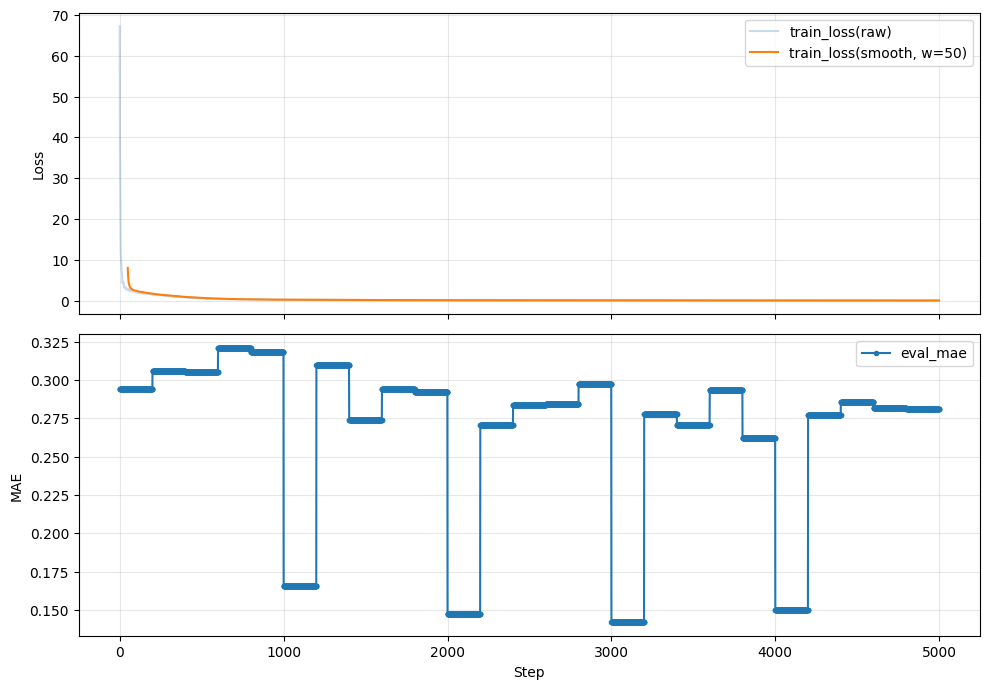

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 训练历史：step_history, train_loss_history, eval_mae_history
steps = np.array(step_history)
train_loss = np.array(train_loss_history, dtype=np.float32)
eval_mae = np.array(eval_mae_history, dtype=np.float32)

# 平滑一下训练loss（可选）
def moving_avg(x, w=50):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

train_loss_smooth = moving_avg(train_loss, w=50)
steps_smooth = steps[len(steps) - len(train_loss_smooth):]

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(steps, train_loss, alpha=0.25, label="train_loss(raw)")
axs[0].plot(steps_smooth, train_loss_smooth, label="train_loss(smooth, w=50)")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

valid = np.isfinite(eval_mae)
axs[1].plot(steps[valid], eval_mae[valid], "o-", markersize=3, label="eval_mae")
axs[1].set_xlabel("Step")
axs[1].set_ylabel("MAE")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


`MAE` 是 **Mean Absolute Error（平均绝对误差）**，这里是动作误差：

$$
\text{MAE} = \frac{1}{N}\sum |a_{\text{pred}} - a_{\text{gt}}|
$$

在你的 ACT 里，通常是对 `action`（7 维关节/夹爪）按 batch、按维度取绝对值再平均。  
数值越小越好，`0` 表示和示教动作完全一致。

你图里“规律波动”主要有这几个原因（都正常）：

1. `eval_freq` 稀疏评估  
你每隔固定 step 才算一次 MAE，所以曲线天然是“台阶状”。

2. `max_eval_batches=2` 太小  
每次只看 2 个 batch，统计方差很大，容易一会高一会低，出现周期性抖动。

3. 评估集不固定（若复用 train dataloader 或 shuffle）  
每次评估样本不同，MAE 会跟着样本难度跳。

4. ACT 是 chunk 预测  
你可能只拿 `target[:,0,:]` 对比，某些时刻刚好更容易/更难，也会形成规律起伏。

你现在这张图的解读：  
- train loss 持续下降，训练在收敛。  
- MAE 在约 `0.15~0.32` 区间震荡，整体略下降但噪声较大。  
- 这更像“评估采样太少导致的测量噪声”，不是训练坏掉。

想让 MAE 更平滑可信，改三点就行：  
1. `max_eval_batches` 提到 `10` 或 `20`。  
2. 用固定 `eval_dataloader(shuffle=False)`。  
3. 固定评估 episode 子集（每次都同一批数据）。

不过还是应该看整体MAE，这样更准确。

In [14]:
# Save the policy to disk.
policy.save_pretrained('./ckpt/act_y')

## 推理测试

在数据集上评估策略时，可以计算预测动作与数据集真值动作之间的误差。


In [15]:
import torch

class EpisodeSampler(torch.utils.data.Sampler):
    def __init__(self, dataset: LeRobotDataset, episode_index: int):
        from_idx = dataset.episode_data_index["from"][episode_index].item()
        to_idx = dataset.episode_data_index["to"][episode_index].item()
        self.frame_ids = range(from_idx, to_idx)

    def __iter__(self):
        return iter(self.frame_ids)

    def __len__(self) -> int:
        return len(self.frame_ids)

In [16]:
policy.eval()
actions = []
gt_actions = []
images = []
episode_index = 0
episode_sampler = EpisodeSampler(dataset, episode_index)
test_dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=num_workers,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")


Mean action error: 0.004


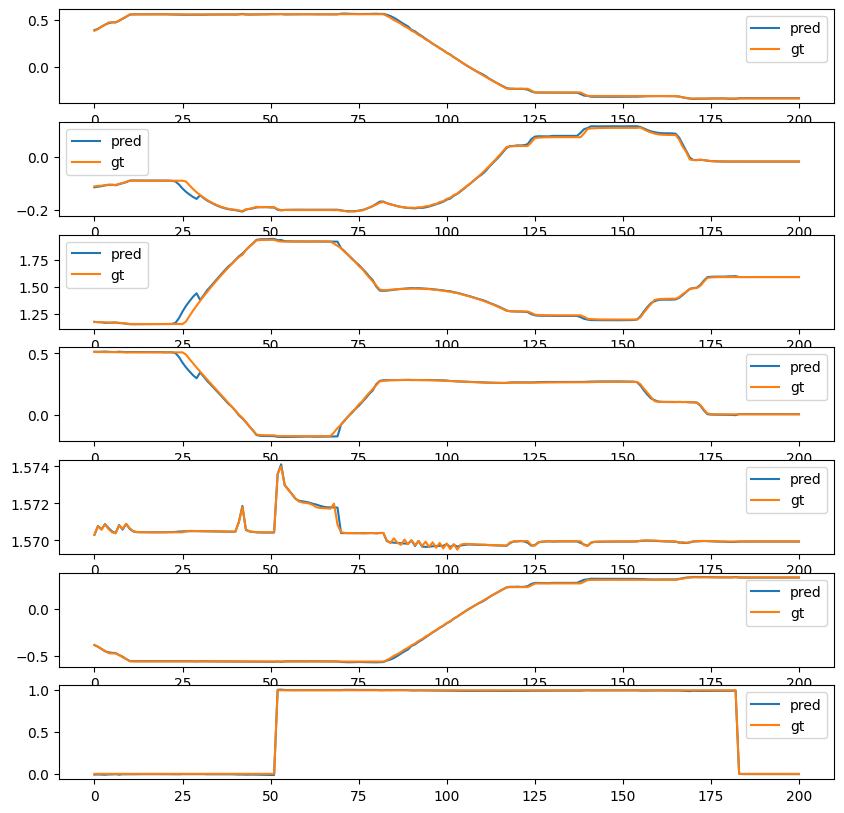

In [17]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))

for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()

如果是把“多个动作/多个 episode”做成分层统计，不要只看单条曲线。

推荐 3 个层级：

per-dim MAE（每个动作维度一个 MAE）
per-episode MAE（每条轨迹一个 MAE）
overall MAE（全部轨迹汇总，外加标准差）
再补两个更稳的指标：

RMSE（更惩罚大误差）
成功率（例如末端误差 < 阈值 的 episode 占比）



结论（单任务下）：
- `1条轨迹`：能过拟合演示，但泛化差，稍微偏离就失败。  
- `多条轨迹`：对初始状态、抓取姿态、时序扰动更鲁棒，ACT 学到的是任务分布，不是单一路径。

一般规律：
- 同任务、数据质量一致时，轨迹数增加通常先显著提升，再边际递减。  
- 低质量/冲突示教太多会拉低效果，所以“数量 + 一致性”都重要。

实操建议：
1. 至少先做 `20-50` 条高质量轨迹（比 1 条稳定很多）。  
2. 覆盖不同初始位置、轻微视角变化、速度变化。  
3. 保证成功率高，失败轨迹要么单独标注，要么先不混。  
4. 固定评估集，比较 `MAE + 成功率`，不要只看 train loss。  

所以你的场景里，多轨迹训练 ACT 基本不会比单条更差，前提是数据标注和操作一致性过关。

In [18]:
import numpy as np
import torch
import imageio.v2 as imageio
from pathlib import Path

# images: 你前面eval循环里 append 的列表，每个元素通常是 [1,3,H,W]
# 先拼成 [T,3,H,W]
img_t = torch.cat(images, dim=0).detach().cpu()  # float tensor, usually [0,1]

# 转成 uint8 [T,H,W,3]
frames = []
for i in range(img_t.shape[0]):
    x = img_t[i].clamp(0, 1).permute(1, 2, 0).numpy()
    x = (x * 255).astype(np.uint8)
    frames.append(x)

out_dir = Path("./eval_videos")
out_dir.mkdir(parents=True, exist_ok=True)
mp4_path = out_dir / "episode0_eval.mp4"
gif_path = out_dir / "episode0_eval.gif"

fps = 20
imageio.mimsave(mp4_path, frames, fps=fps, quality=8)
imageio.mimsave(gif_path, frames, fps=10)

print(f"saved mp4: {mp4_path.resolve()}")
print(f"saved gif: {gif_path.resolve()}")


saved mp4: C:\Users\kewei\Documents\2025\04资料整理\03具身教程编写\ai-hardware-robotics\12-待定开源教程\lerobot-mujoco-tutorial\eval_videos\episode0_eval.mp4
saved gif: C:\Users\kewei\Documents\2025\04资料整理\03具身教程编写\ai-hardware-robotics\12-待定开源教程\lerobot-mujoco-tutorial\eval_videos\episode0_eval.gif


In [19]:
from pathlib import Path
import numpy as np

# 你之前训练循环里的列表
# step_history, train_loss_history, eval_mae_history

out_dir = Path("./logs_txt")
out_dir.mkdir(parents=True, exist_ok=True)

steps = np.asarray(step_history, dtype=np.int64)
loss = np.asarray(train_loss_history, dtype=np.float32)
mae = np.asarray(eval_mae_history, dtype=np.float32)

# 1) 各自单独保存
np.savetxt(out_dir / "train_loss.txt", loss, fmt="%.8f")
np.savetxt(out_dir / "eval_mae.txt", mae, fmt="%.8f")

# 2) 合并保存（推荐，便于后续画图）
# 列: step,train_loss,eval_mae
merged = np.column_stack([steps, loss, mae])
np.savetxt(
    out_dir / "train_loss_mae.txt",
    merged,
    fmt=["%d", "%.8f", "%.8f"],
    delimiter=",",
    header="step,train_loss,eval_mae",
    comments=""
)

print("saved:", (out_dir / "train_loss.txt").resolve())
print("saved:", (out_dir / "eval_mae.txt").resolve())
print("saved:", (out_dir / "train_loss_mae.txt").resolve())


saved: C:\Users\kewei\Documents\2025\04资料整理\03具身教程编写\ai-hardware-robotics\12-待定开源教程\lerobot-mujoco-tutorial\logs_txt\train_loss.txt
saved: C:\Users\kewei\Documents\2025\04资料整理\03具身教程编写\ai-hardware-robotics\12-待定开源教程\lerobot-mujoco-tutorial\logs_txt\eval_mae.txt
saved: C:\Users\kewei\Documents\2025\04资料整理\03具身教程编写\ai-hardware-robotics\12-待定开源教程\lerobot-mujoco-tutorial\logs_txt\train_loss_mae.txt


## 🤖 机器人 ACT 的核心奥秘：为什么它这么强？

传统的机器人控制往往是“看一眼，动一下”，这种方式容易导致动作迟钝、磕磕绊绊。ACT 换了个思路，它像是一个**钢琴家**：不是思考下一个音符弹什么，而是脑子里已经有了一小段旋律。

### 1. 动作分块 (Action Chunking)：拒绝“帕金森”

代码中的 `chunk_size=10` 就是核心。ACT 不仅仅预测当前的动作，它会一次性预测未来 $k$ 个步长（比如 10 步或 100 步）的一整串动作。

- **好处：** 动作之间有连贯性，减少了因为网络计算延迟导致的“手抖”现象。

### 2. CVAE：应对“选择困难症”

人类教机器人做动作时，同样一个任务（比如抓瓶子），每次的手势可能略有不同。普通的模型会把这些不同的教法“平均化”，导致机器人最后做出了一个四不像的动作。

ACT 引入了 **CVAE (条件变分自编码器)**。它会学习专家演示中的潜在风格（Latent Style）。

- **原理：** 训练时，它把动作序列压缩成一个隐含空间；推理时，它从这个空间采样，确保输出的动作既符合当前画面，又是逻辑自洽的“一整套方案”。

### 3. 时间集成 (Temporal Ensembling)：给动作加“磨皮滤镜”

代码里虽然没直接写出，但 ACT 在执行时有个绝活：它每步都会预测后面 10 步，这意味着对于第 $t$ 时刻，其实有多个重叠的预测方案。ACT 会把这些方案进行**加权平均**。

- **效果：** 极大地增加了动作的平滑度，让机械臂动起来像人手一样柔顺。

------

## 🔍 代码细节拆解

结合你提供的 `LeRobot` 代码片段，我们来看看这些关键参数在干什么：

| **参数**            | **俗称**       | **实际作用**                                                 |
| ------------------- | -------------- | ------------------------------------------------------------ |
| `chunk_size=10`     | **连招长度**   | 预测未来 10 个动作帧。值越大，动作越连贯，但对长时建模要求越高。 |
| `n_action_steps=10` | **执行步数**   | 模型预测了 10 步，实际执行几步？通常与 chunk_size 保持一致。 |
| `dataset_stats`     | **归一化字典** | 机器人的关节角度坐标系各异，必须根据数据集的均值/方差进行标准化，否则模型会“跑飞”。 |
| `input_features`    | **感知全家桶** | 包含相机图像、机械臂当前关节位置（Qpos）。注意代码里剔除了手腕相机，只留了主视角。 |

------

## 🌟 为什么它在 `LeRobot` 里这么火？

`LeRobot` 是 Hugging Face 推出的机器人开源库，而 ACT 正是其中的明星策略。它的应用场景非常生动：

- **精细操作：** 拉拉链、系鞋带、翻转煎蛋卷。
- **抗干扰：** 即使你轻轻推一下机械臂，因为它预测的是一串连续动作，它能展现出更强的鲁棒性。

> **💡 举个例子：**
>
> 如果用旧方法教机器人折衣服，它可能在手碰到衣服的一瞬间停顿一下，思考“接下来怎么捏”；
>
> 用了 **ACT**，它在手伸向衣服的过程中，脑子里已经规划好了“捏住-提起-折叠”的整套弧线。

## 🛠️ 如何调整 `chunk_size` 优化抓取？

在 ACT 模型中，`chunk_size` 决定了机器人一次性规划多远的未来。调整它时，你可以参考以下这个“平衡木”准则：

### 1. 较小的 `chunk_size` (例如 1-10)

- **表现：** 机器人变得非常“敏感”和“多疑”。它会高频地重新观察世界并修正动作。
- **优点：** 能够快速响应环境变化（比如你突然把杯子挪位了）。
- **缺点：** 容易出现**抖动**（类似帕金森症状），因为 Transformer 在每一帧预测的动作可能不完全连续。
- **适用场景：** 需要高频闭环反馈、精细避障或目标会移动的任务。

### 2. 较大的 `chunk_size` (例如 30-100)

- **表现：** 机器人动起来像在跳芭蕾，动作极其丝滑连贯。
- **优点：** 动作非常自然，克服了单帧预测的不稳定性，能完成复杂的长程任务（如打个死结）。
- **缺点：** 产生**“盲目性”**。如果机器人正在执行这 100 步连招，即使环境变了，它也要把这套招式耍完才会看下一眼。
- **适用场景：** 环境相对静止、需要动作极度平滑的精细操作（如翻开书页）。

> **💡 调参秘籍：** > 大多数抓取任务的“甜点区”在 **20 到 60** 之间。如果你的机器人看起来动作迟钝、跟不上物体移动，减小它；如果它动作频繁颤抖，加大它。

------

## 📥 ACT 模型的输入与输出是什么？

ACT 本质上是一个“多模态到序列”的翻译官。

### 1. 输入 (Inputs)：它“看”到了什么？

ACT 的输入通常包含两部分信息，这模拟了人类的**视觉**和**肌肉感知**：

- **视觉观察 (Visual Observations)：**
  - **主视角图像 (Top/Front Camera)：** 提供全局信息（物体在哪里，障碍物在哪里）。
  - **手腕相机图像 (Wrist Camera)：** 提供局部细节（夹爪离物体还有几毫米）。*（注意：你提供的代码中 `pop` 掉了这个，说明该实验只用了主视角）*
- **本体感受 (Proprioception / State)：**
  - **当前关节角度 ($q_{pos}$)：** 机器人得知道自己现在的“手脚”在哪儿，才能规划下一步去哪儿。通常是一个 6 或 7 维的向量。

### 2. 输出 (Outputs)：它“打算”做什么？

ACT 的输出不再是一个简单的“下一刻坐标”，而是一个**动作矩阵**：

- **动作序列 (Action Chunk)：**
  - 形状通常为 `(chunk_size, action_dim)`。
  - 它包含从当前时刻 $t$ 到 $t + \text{chunk\_size}$ 的所有预想动作（如各关节的目标角度）。
- **样式向量 (Style Variable/Latent $z$)：**
  - 在训练阶段，CVAE 会输出一个关于动作风格的分布，帮助模型在面对“多种可能的正确解”时保持逻辑自洽。

------

## 🔄 流程拆解：从输入到动作

1. **感知：** 拍下照片，读取当前关节角度。
2. **联想：** 将图像和角度喂给 Transformer 编码器。
3. **决策：** Transformer 解码器一次性“喷出”接下来 $N$ 步（`chunk_size`）的全部动作。
4. **执行：** 机器人按照这 $N$ 步走下去。
5. **集成：** 在走的过程中（比如走到第 2 步时），模型其实又在计算下一组 $N$ 步了。ACT 会把**新预测的动作**和**正在执行的旧动作**按时间权重“揉合”在一起，实现无缝衔接。